# Seoul Bike Demand Forecasting

This notebook evaluates Seoul bike demand through three connected workflows:

1. A baseline univariate ARIMA forecast for daily rental demand.
2. An ARIMAX forecast that adds temperature as an external regressor.
3. A Random Forest model to identify the most influential predictors.

The notebook uses one shared dataset-loading step and then branches into task-specific modeling sections.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.arima.model import ARIMA
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score

# Load the Seoul bike dataset once and parse the date field.
df = pd.read_csv('SeoulBikeData.csv', encoding='unicode_escape')
df['Date'] = pd.to_datetime(df['Date'], format='%d/%m/%Y')

print('Dataset Shape:', df.shape)
print(df.head(2))

Dataset Shape: (8760, 14)
         Date  Rented Bike Count  Hour  Temperature(°C)  Humidity(%)  \
0  01/12/2017                254     0             -5.2           37   
1  01/12/2017                204     1             -5.5           38   

   Wind speed (m/s)  Visibility (10m)  Dew point temperature(°C)  \
0               2.2              2000                      -17.6   
1               0.8              2000                      -17.6   

   Solar Radiation (MJ/m2)  Rainfall(mm)  Snowfall (cm) Seasons     Holiday  \
0                      0.0           0.0            0.0  Winter  No Holiday   
1                      0.0           0.0            0.0  Winter  No Holiday   

  Functioning Day  
0             Yes  
1             Yes  


## Baseline ARIMA Forecast

This section builds a univariate ARIMA model using only past rental counts to establish a simple time-series baseline.

--- Standard ARIMA Forecast Preview ---
2018-12-01    15804.120239
2018-12-02    15764.621320
2018-12-03    15761.455913
2018-12-04    15761.202241
2018-12-05    15761.181912
Freq: D, Name: predicted_mean, dtype: float64


/Users/xliang/ARIMA Random forest/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/xliang/ARIMA Random forest/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/xliang/ARIMA Random forest/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


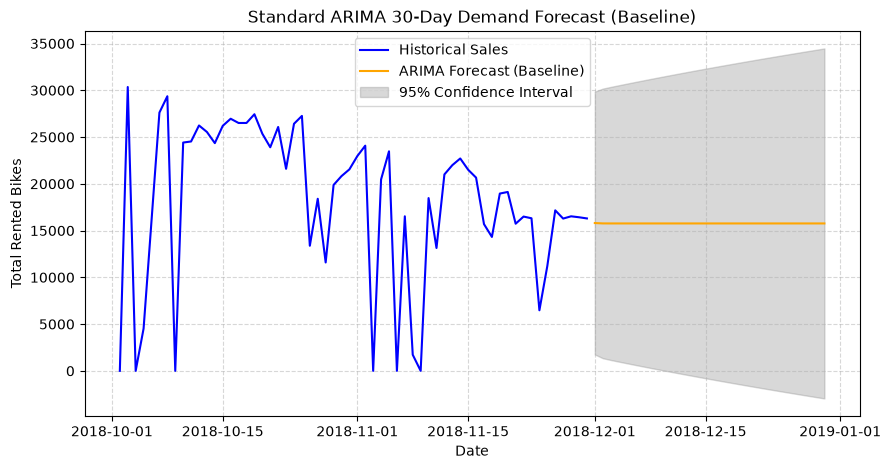

In [ ]:
# Aggregate daily rental counts for the baseline ARIMA model
daily_df = df.groupby('Date').agg({
    'Rented Bike Count': 'sum'
}).reset_index()

daily_df['Date'] = pd.to_datetime(daily_df['Date'], format='%d/%m/%Y')
daily_df.set_index('Date', inplace=True)

y = daily_df['Rented Bike Count']

# Fit the baseline ARIMA model
model = ARIMA(y, order=(1, 1, 1))
model_fit = model.fit()

forecast_steps = 30
forecast_result = model_fit.get_forecast(steps=forecast_steps)
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

print('--- Standard ARIMA Forecast Preview ---')
print(forecast_mean.head())

# Plot forecast results
plt.figure(figsize=(10, 5))
plt.plot(daily_df.index[-60:], y[-60:], label='Historical Demand', color='blue')
plt.plot(forecast_mean.index, forecast_mean, label='ARIMA Forecast (Baseline)', color='orange')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='gray', alpha=0.3, label='95% Confidence Interval')
plt.title('Standard ARIMA 30-Day Demand Forecast (Baseline)')
plt.xlabel('Date')
plt.ylabel('Total Rented Bikes')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## ARIMAX Forecast

This section extends the baseline approach by incorporating temperature as an exogenous variable, improving the model with additional real-world context.

--- ARIMAX Forecast Preview ---
2018-12-01    17346.604968
2018-12-02    17166.079646
2018-12-03    17146.338687
2018-12-04    17144.179957
2018-12-05    17143.943894
Freq: D, Name: predicted_mean, dtype: float64


/Users/xliang/ARIMA Random forest/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/xliang/ARIMA Random forest/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Users/xliang/ARIMA Random forest/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


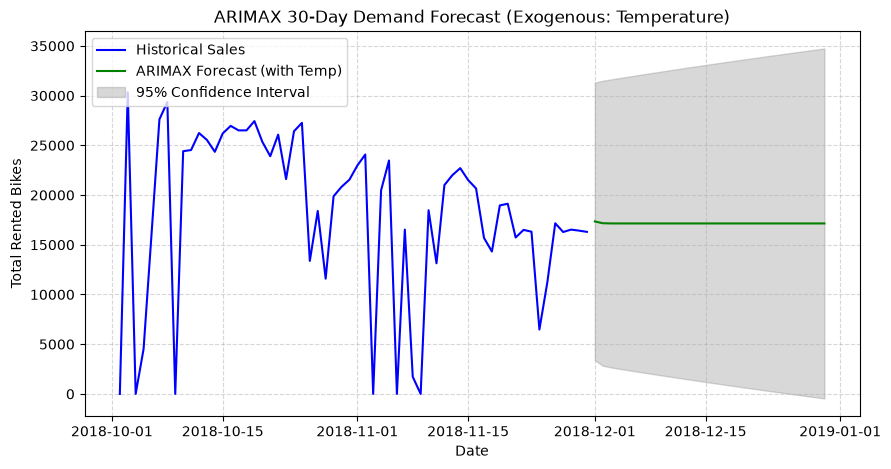

In [ ]:
# Aggregate daily totals and daily mean temperature for ARIMAX
# This keeps the time-series model focused on daily demand trends.
daily_df = df.groupby('Date').agg({
    'Rented Bike Count': 'sum',
    'Temperature(°C)': 'mean'
}).reset_index()

daily_df['Date'] = pd.to_datetime(daily_df['Date'], format='%d/%m/%Y')
daily_df.set_index('Date', inplace=True)

y = daily_df['Rented Bike Count']
exog = daily_df[['Temperature(°C)']]

# Build a 30-day forecast for the exogenous variable
forecast_steps = 30
future_dates = pd.date_range(start=y.index[-1] + pd.Timedelta(days=1), periods=forecast_steps)
future_exog = pd.DataFrame({
    'Temperature(°C)': [exog['Temperature(°C)'].iloc[-30:].mean()] * forecast_steps
}, index=future_dates)

# Fit the ARIMAX model
model = ARIMA(y, exog=exog, order=(1, 1, 1))
model_fit = model.fit()

forecast_result = model_fit.get_forecast(steps=forecast_steps, exog=future_exog)
forecast_mean = forecast_result.predicted_mean
conf_int = forecast_result.conf_int()

print('--- ARIMAX Forecast Preview ---')
print(forecast_mean.head())

# Plot forecast results
plt.figure(figsize=(10, 5))
plt.plot(daily_df.index[-60:], y[-60:], label='Historical Demand', color='blue')
plt.plot(forecast_mean.index, forecast_mean, label='ARIMAX Forecast', color='green')
plt.fill_between(conf_int.index, conf_int.iloc[:, 0], conf_int.iloc[:, 1], color='gray', alpha=0.3, label='95% Confidence Interval')
plt.title('ARIMAX 30-Day Demand Forecast (Exogenous: Temperature)')
plt.xlabel('Date')
plt.ylabel('Total Rented Bikes')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

## Random Forest Feature Importance

This section prepares the feature matrix, trains a Random Forest regressor, and reports the most influential predictors for bike demand.


--- Random Forest Model Performance ---
RMSE: 388.8151
R2 Score: 0.6311

--- Feature Importance Ranking ---
                    Feature  Importance
0           Temperature(°C)    0.406494
1               Humidity(%)    0.229023
4   Solar Radiation (MJ/m2)    0.137665
2          Wind speed (m/s)    0.095350
3          Visibility (10m)    0.068041
9            Seasons_Winter    0.016236
7            Seasons_Spring    0.016035
5              Rainfall(mm)    0.015097
8            Seasons_Summer    0.008322
10       Holiday_No Holiday    0.007154


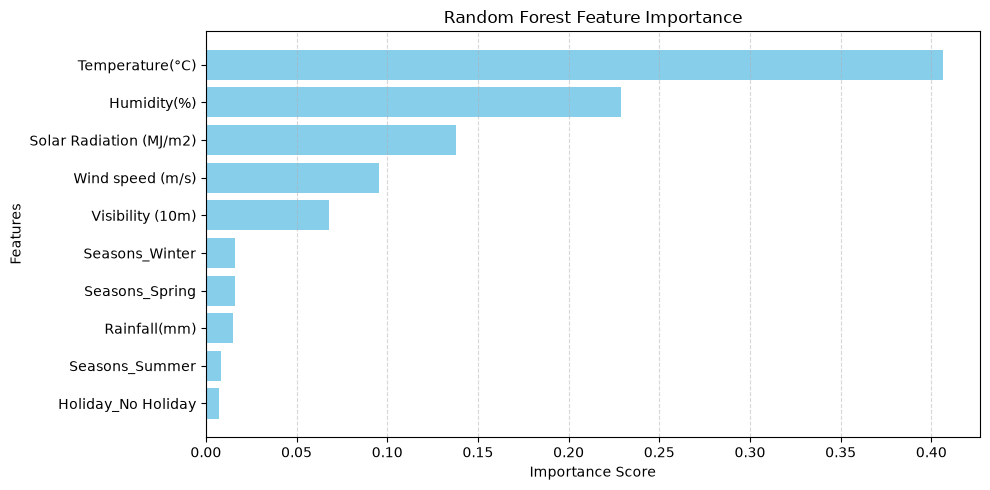

In [ ]:
# Prepare the feature matrix for the Random Forest model
# Keep only the relevant numeric predictors and one-hot encoded seasonal/holiday flags.
df_model = pd.get_dummies(df, columns=['Seasons', 'Holiday', 'Functioning Day'], drop_first=True)

features = [
    'Temperature(°C)', 'Humidity(%)', 'Wind speed (m/s)', 'Visibility (10m)',
    'Solar Radiation (MJ/m2)', 'Rainfall(mm)', 'Snowfall (cm)'
]

X = df_model[[col for col in df_model.columns if col in features or 'Seasons_' in col or 'Holiday_' in col]]
y = df_model['Rented Bike Count']

# Split into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Train the regressor
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print('\n--- Random Forest Model Performance ---')
print(f'RMSE: {rmse:.4f}')
print(f'R2 Score: {r2:.4f}')

# Rank the feature importances
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': rf.feature_importances_
}).sort_values(by='Importance', ascending=False)

print('\n--- Feature Importance Ranking ---')
print(feature_importance.head(10))

# Plot the top 10 most important features
plt.figure(figsize=(10, 5))
plt.barh(feature_importance['Feature'][:10][::-1], feature_importance['Importance'][:10][::-1], color='skyblue')
plt.title('Random Forest Feature Importance')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()